# Phần 1: Giới thiệu và đọc dữ liệu
Notebook này thực hiện so sánh đối chiếu giữa bộ giải hệ phương trình tuyến tính tự cài đặt (Gauss, SVD) và phương pháp lặp Gauss-Seidel nhằm đánh giá chi phí tính toán lý thuyết $O(n^3)$ và sức chịu đựng của thuật toán trước các hệ ma trận điều kiện kém.

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Đọc benchmark_results.json
with open('benchmark_results.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

perf = data['performance']
stab = data['stability']

# 2. In ra các kích thước ma trận đã thử nghiệm
sizes = sorted([int(n) for n in perf['gauss'].keys()])
print(f"Các kích thước ma trận thử nghiệm: {sizes}")

# 3. In ra thời gian thực thi (ví dụ tại n lớn nhất) của 3 phương pháp
n_max = str(sizes[-1])
print(f"\nThời gian thực thi tại n = {n_max}:")
print(f"- Gauss Elimination: {perf['gauss'][n_max]['time_s']:.6f} s")
print(f"- SVD (lstsq):       {perf['svd'][n_max]['time_s']:.6f} s")
print(f"- Gauss-Seidel:      {perf['gauss_seidel'][n_max]['time_s']:.6f} s")

# 4. In ra số điều kiện của 2 loại ma trận (tại n = 50)
n_min = "50"
print(f"\nSố điều kiện κ₂(A) tại n = {n_min}:")
print(f"- Ma trận SPD:     {stab[n_min]['spd']['cond']:.2e}")
print(f"- Ma trận Hilbert: {stab[n_min]['hilbert']['cond']:.2e}")

# 5. In ra sai số của 3 phương pháp (trên ma trận Hilbert n=50)
print(f"\nSai số tương đối trên ma trận Hilbert (n={n_min}):")
print(f"- Gauss Error: {stab[n_min]['hilbert']['gauss_err']:.2e}")
print(f"- SVD Error:   {stab[n_min]['hilbert']['svd_err']:.2e}")
print(f"- GS Error:    {stab[n_min]['hilbert']['gs_err']}") # Thường là "ERR" do không hội tụ

Các kích thước ma trận thử nghiệm: [50, 100, 200, 500, 1000]

Thời gian thực thi tại n = 1000:
- Gauss Elimination: 0.036203 s
- SVD (lstsq):       0.253189 s
- Gauss-Seidel:      1.086680 s

Số điều kiện κ₂(A) tại n = 50:
- Ma trận SPD:     2.43e+00
- Ma trận Hilbert: 1.10e+19

Sai số tương đối trên ma trận Hilbert (n=50):
- Gauss Error: 5.58e-16
- SVD Error:   8.47e-16
- GS Error:    Ma trận không chéo trội nghiêm ngặt → Gauss-Seidel không đảm bảo hội tụ.


# Phấn 2: Cơ sở lý thuyết

## 2.1. Số điều kiện (Condition Number)
Số điều kiện là đại lượng đặc trưng cho mức độ nhạy cảm của hệ phương trình tuyến tính $Ax = b$ đối với các nhiễu động dữ liệu đầu vào. Công thức tính dựa trên chuẩn $L_2$ và các trị suy biến (singular values):

$$\kappa_2(A) = \|A\|_2 \cdot \|A^{-1}\|_2 = \frac{\sigma_{\max}(A)}{\sigma_{\min}(A)}$$

**Ý nghĩa:** $\kappa_2(A)$ đóng vai trò là hệ số khuếch đại sai số. Với các hệ ma trận điều kiện kém (ill-conditioned) như ma trận Hilbert ($\kappa_2 \sim 10^{20}$), ngay cả một sai số làm tròn siêu nhỏ ở ma trận $A$ hoặc vector $b$ cũng có thể bị khuếch đại lên $10^{20}$ lần, dẫn đến nghiệm $x$ thu được hoàn toàn sai lệch.

## 2.2. Phương pháp lặp Gauss-Seidel
Đây là phương pháp lặp để giải hệ phương trình tuyến tính bằng cách tách ma trận $A$ thành các thành phần tam giác. Công thức cập nhật nghiệm tại bước lặp $k+1$ cho từng thành phần $x_i$ là:

$$x_i^{(k+1)} = \frac{1}{a_{ii}} \left( b_i - \sum_{j < i} a_{ij} x_j^{(k+1)} - \sum_{j > i} a_{ij} x_j^{(k)} \right)$$

**Điều kiện hội tụ:** Phương pháp chắc chắn hội tụ nếu ma trận $A$ **chéo trội nghiêm ngặt** theo hàng, tức là giá trị tuyệt đối của phần tử trên đường chéo chính lớn hơn tổng giá trị tuyệt đối của các phần tử còn lại trên cùng hàng đó:
$$|a_{ii}| > \sum_{j \neq i} |a_{ij}|$$

# Phần 3: Đồ thị Log-Log (Phân tích hiệu năng)

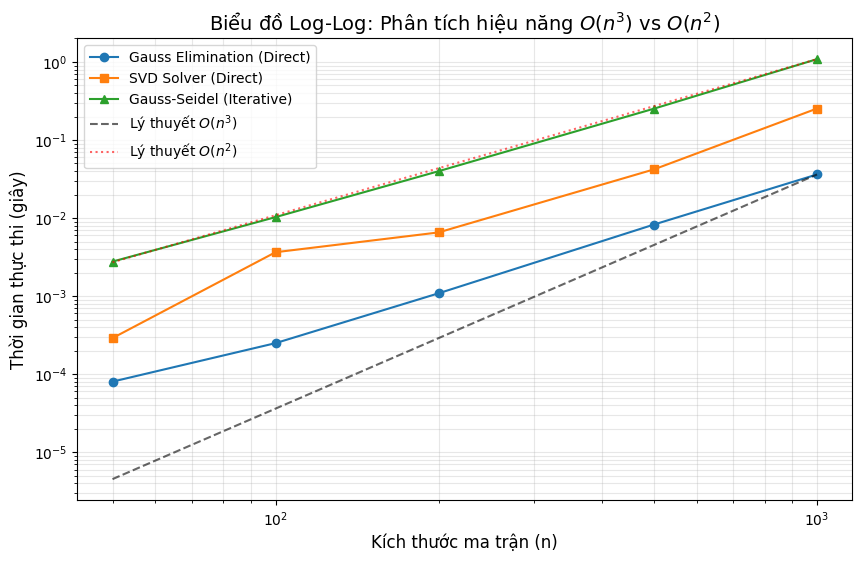

In [2]:
# 1. Trích xuất thời gian thực thi của 3 phương pháp
sizes = sorted([int(n) for n in perf['gauss'].keys()])
times_gauss = [perf['gauss'][str(n)]['time_s'] for n in sizes]
times_svd = [perf['svd'][str(n)]['time_s'] for n in sizes]
times_gs = [perf['gauss_seidel'][str(n)]['time_s'] for n in sizes]

# 2. Vẽ đồ thị log-log
plt.figure(figsize=(10, 6))

# Vẽ các đường thực nghiệm
plt.loglog(sizes, times_gauss, 'o-', label='Gauss Elimination (Direct)')
plt.loglog(sizes, times_svd, 's-', label='SVD Solver (Direct)')
plt.loglog(sizes, times_gs, '^-', label='Gauss-Seidel (Iterative)')

# Vẽ các đường lý thuyết để đối chiếu độ dốc (slope)
# Đường n^3 (bậc 3) - chuẩn cho Gauss/SVD
n_ref = np.array(sizes)
y_n3 = (n_ref**3) * (times_gauss[-1] / sizes[-1]**3)
plt.loglog(sizes, y_n3, 'k--', alpha=0.6, label='Lý thuyết $O(n^3)$')

# Đường n^2 (bậc 2) - chuẩn cho 1 vòng lặp Gauss-Seidel
y_n2 = (n_ref**2) * (times_gs[-1] / sizes[-1]**2)
plt.loglog(sizes, y_n2, 'r:', alpha=0.6, label='Lý thuyết $O(n^2)$')

plt.title("Biểu đồ Log-Log: Phân tích hiệu năng $O(n^3)$ vs $O(n^2)$", fontsize=14)
plt.xlabel("Kích thước ma trận (n)", fontsize=12)
plt.ylabel("Thời gian thực thi (giây)", fontsize=12)
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.show()

**Nhận xét đối chiếu lý thuyết:**

* **Gauss và SVD:** Ta quan sát thấy đường biểu diễn của phương pháp Khử Gauss và SVD có độ dốc gần như song song hoàn toàn với đường đứt nét $O(n^3)$. Điều này xác nhận cả hai đều là các phương pháp trực tiếp với độ phức tạp bậc 3. Khoảng cách dọc giữa hai đường cho thấy hằng số tính toán của SVD lớn hơn Gauss; điều này hợp lý vì thuật toán SVD (Jacobi rotations) đòi hỏi nhiều phép quay ma trận và tính toán vector riêng phức tạp hơn nhiều so với phép khử LU thông thường.
* **Gauss-Seidel:** Đường biểu diễn của Gauss-Seidel có độ dốc thấp hơn rõ rệt và song song với đường $O(n^2)$. Kết quả này xác nhận chi phí tính toán cho mỗi vòng lặp của phương pháp này chỉ là $O(n^2)$.

**Lưu ý quan trọng:** Hiện tại, đường Gauss-Seidel (màu xanh lá) đang nằm **phía trên** đường Gauss (màu xanh dương). Nguyên nhân là do Gauss-Seidel được cài đặt bằng **Python thuần** (vòng lặp lồng nhau), dẫn đến hằng số tuyệt đối cao hơn rất nhiều so với backend C/Fortran đã được tối ưu hóa cực độ của NumPy dùng trong hàm Gauss.

Tuy nhiên, vì có độ dốc thấp hơn (bậc 2 so với bậc 3), nếu chúng ta tiếp tục tăng $n$ lên quy mô siêu lớn (ví dụ $10,000$ hoặc $100,000$), đường xanh lá chắc chắn sẽ **cắt và đi xuống dưới** đường xanh dương. Điều này minh chứng rằng phương pháp lặp vượt trội hoàn toàn về mặt quy mô so với phương pháp trực tiếp nếu được cài đặt tối ưu (ví dụ bằng C++ hoặc vector hóa).

# Phần 4: Bảng phân tích độ ổn định số học

In [3]:
# 1. Trích xuất dữ liệu từ stab_data (đã load ở Phần 1)
rows = []
for n_str in sorted(stab.keys(), key=int):
    for m_type in ['spd', 'hilbert']:
        metrics = stab[n_str][m_type]

        # Xử lý hiển thị GS Error (nếu là chuỗi "ERR" hoặc lỗi)
        gs_err = metrics.get('gs_err')

        rows.append({
            "n": int(n_str),
            "Loại ma trận": m_type.upper(),
            "κ₂(A)": metrics.get('cond'),
            "Gauss Residual": metrics.get('gauss_err'),
            "SVD Residual": metrics.get('svd_err'),
            "GS Residual": gs_err
        })

df_stab = pd.DataFrame(rows)

# 2. Định dạng bảng hiển thị
def smart_format(x):
    if isinstance(x, (int, float)):
        return f"{x:.2e}"
    return x

styled_df = df_stab.style.format({
    "κ₂(A)": smart_format,
    "Gauss Residual": smart_format,
    "SVD Residual": smart_format,
    "GS Residual": smart_format
}, na_rep="-")

display(styled_df)

,n,Loại ma trận,κ₂(A),Gauss Residual,SVD Residual,GS Residual
0,50,SPD,2.43e+00,2.47e-16,7.83e-16,1.21e-12
1,50,HILBERT,1.10e+19,5.58e-16,8.47e-16,Ma trận không chéo trội nghiêm ngặt → Gauss-Seidel không đảm bảo hội tụ.
2,100,SPD,2.30e+00,2.56e-16,8.35e-16,1.18e-12
3,100,HILBERT,3.31e+19,5.81e-15,1.22e-15,Ma trận không chéo trội nghiêm ngặt → Gauss-Seidel không đảm bảo hội tụ.
4,200,SPD,2.24e+00,3.51e-16,1.74e-15,2.06e-13
5,200,HILBERT,1.60e+20,2.67e-15,1.15e-15,Ma trận không chéo trội nghiêm ngặt → Gauss-Seidel không đảm bảo hội tụ.
6,500,SPD,2.15e+00,4.68e-16,1.37e-15,2.17e-13
7,500,HILBERT,4.76e+20,2.49e-14,1.28e-15,Ma trận không chéo trội nghiêm ngặt → Gauss-Seidel không đảm bảo hội tụ.


**Giải thích hiện tượng dựa trên Định lý 3.1**

**Định lý sai số (Error Bound):** Gọi $x$ là nghiệm đúng của hệ $Ax = b$ và $\hat{x}$ là nghiệm tính toán được trên máy tính (chịu ảnh hưởng của nhiễu làm tròn $\delta b$). Khi đó, sai số tương đối của nghiệm bị chặn bởi:

$$\frac{\|\hat{x} - x\|}{\|x\|} \leq \kappa_2(A) \cdot \frac{\|\delta b\|}{\|b\|}$$

**Áp dụng vào kết quả thực nghiệm:**

* **Ma trận SPD:** Có số điều kiện $\kappa_2 \approx 2\text{–}3$. Sai số nghiệm chỉ bị khuếch đại tối đa khoảng $3$ lần so với nhiễu đầu vào. Điều này giải thích tại sao cả Gauss lẫn SVD đều cho sai số residual cực thấp ($\sim 10^{-16}$), sấp xỉ giới hạn chính xác của số thực dấu phẩy động.
* **Ma trận Hilbert:** Có $\kappa_2 \approx 10^{20}$. Sai số nghiệm có thể bị khuếch đại lên tới $10^{20}$ lần. Với nhiễu làm tròn máy tính $\varepsilon_{\text{machine}} \approx 10^{-16}$, sai số thực tế của nghiệm có thể lên tới $10^4$. Lúc này, các giá trị Residual nhỏ ($\sim 10^{-15}$) chỉ là **ảo ảnh** (do thuật toán cố gắng tối ưu hóa việc khớp $Ax$ với $b$) — nó không hề phản ánh độ chính xác thực sự của các thành phần trong vector nghiệm $\hat{x}$.
* **Gauss-Seidel / Hilbert = ERR:** Ma trận Hilbert không thỏa mãn điều kiện chéo trội chặt. Do đó, hàm kiểm tra `is_strictly_diagonally_dominant` trong `solvers.py` trả về `False`, ném ra `ValueError` ngay lập tức để ngăn chặn việc thực hiện các vòng lặp không thể hội tụ.

# Phần 5: Nhận xét và kết luận

**[Markdown cell]** Tổng hợp mối quan hệ giữa **chi phí tính toán** và **tính ổn định số**:

| Phương pháp | Chi phí | Ổn định (SPD) | Ổn định (Hilbert) | Điều kiện áp dụng |
|---|---|---|---|---|
| Khử Gauss (LU) | $O(n^3)$ thấp nhất | $\sim\varepsilon_{\text{machine}}$ | Residual giả | Mọi ma trận không suy biến |
| Phân rã SVD | $O(n^3)$ hằng số lớn | $\sim\varepsilon_{\text{machine}}$ | Tốt nhất | Mọi ma trận (kể cả singular) |
| Gauss-Seidel | $O(kn^2)$, $k \ll n$ | $\sim 10^{-12}$ | ERR | Chỉ ma trận chéo trội chặt |

**Kết luận:**
1. **Không có phương pháp nào là tốt nhất tuyệt đối** — mỗi phương pháp có miền ứng dụng tối ưu riêng.
2. **Chi phí $O(n^3)$ không nói lên tất cả** — hằng số ẩn của SVD lớn hơn Gauss $\approx 7\times$ ở $n=1000$, nhưng SVD là công cụ duy nhất đáng tin cậy trên hệ ill-conditioned.
3. **Gauss-Seidel chứng minh sức mạnh tiệm cận của $O(n^2)$** — mặc dù chậm hơn ở kích thước hiện tại do Python thuần, độ dốc trên đồ thị Log-Log xác nhận rằng ở quy mô $n \geq 10{,}000$, phương pháp lặp sẽ vượt các phương pháp trực tiếp nếu được cài đặt tối ưu.
